In [63]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

%matplotlib inline

In [54]:
names_store = [nn.lower().strip() for n in pd.read_csv("Popular Baby Names.csv")["Child's First Name"].unique().tolist() for nn in n.split() if "'" not in nn]
len(names_store)

3302

In [55]:
names_store[:10]

['chloe',
 'olivia',
 'emma',
 'mia',
 'ava',
 'amelia',
 'evelyn',
 'sophia',
 'aria',
 'emily']

In [56]:
ctoi = {'.': 0}

for i in range(97, 123):
    ctoi[chr(i)] = i-96

itoc = {v:k for k,v in ctoi.items()}
itoc

{0: '.',
 1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z'}

In [78]:
cmap = torch.zeros(27,27)

for word in names_store[:]:
    word = "." + word + "."
    for c1, c2 in zip(word, word[1:]):
        try:
            ix1, ix2 = ctoi[c1], ctoi[c2]
            cmap[ix1][ix2] += 1
        except:
            print(word)
            raise
        # print(c1, c2)

cmap.shape

torch.Size([27, 27])

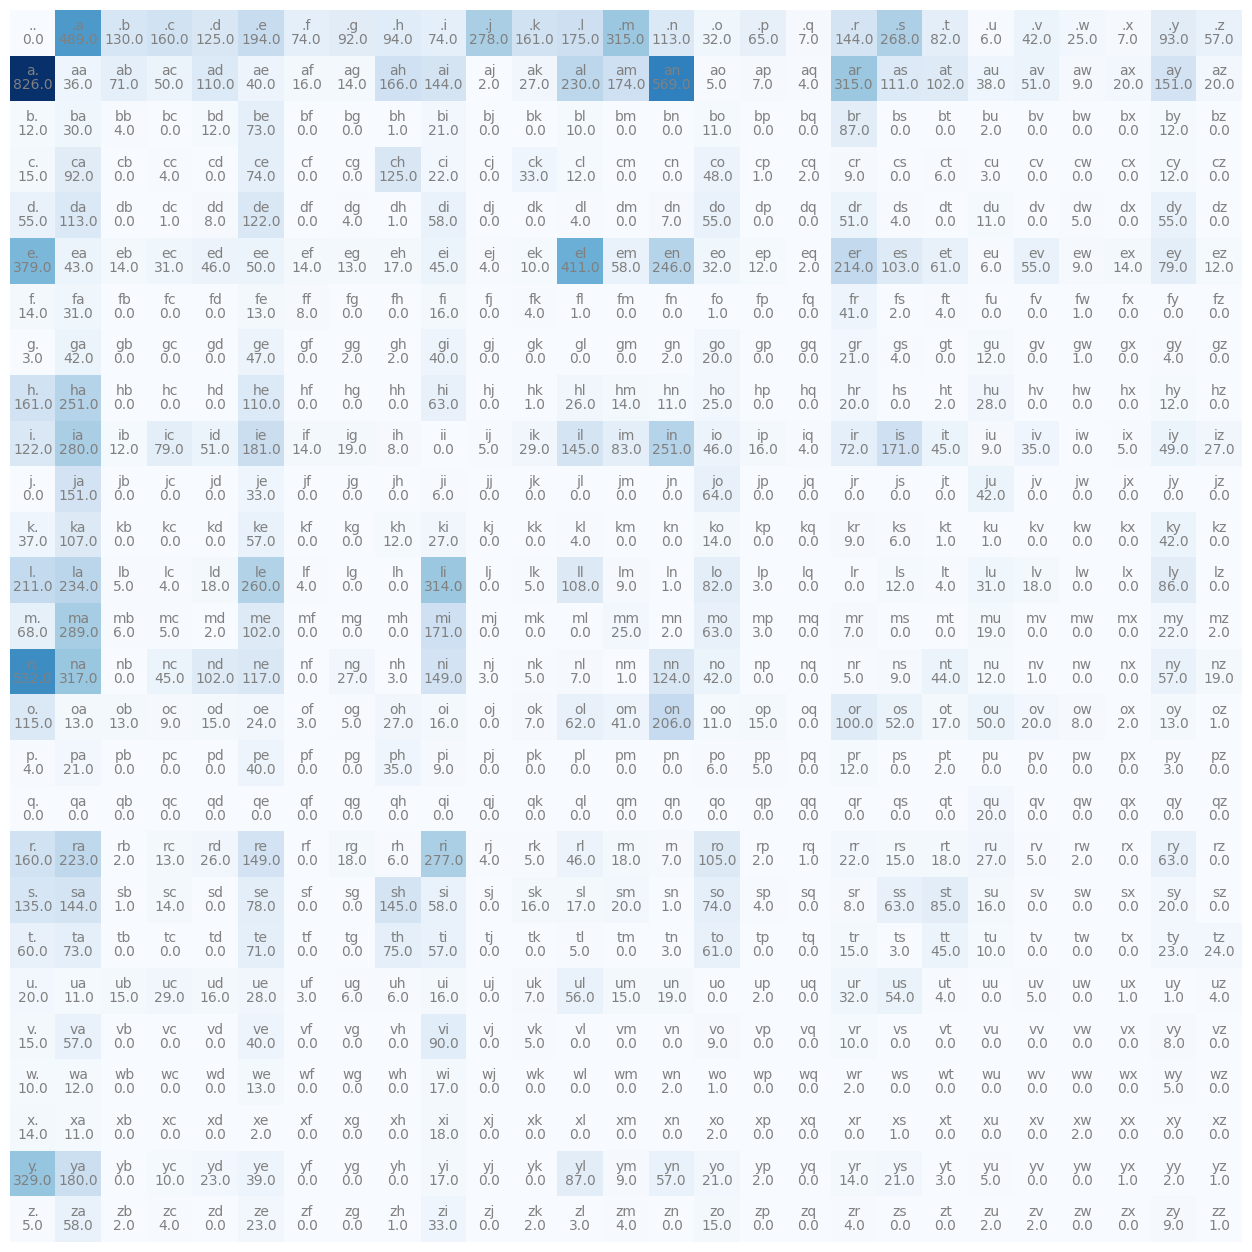

In [83]:
plt.figure(figsize=(16,16))
plt.imshow(cmap, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itoc[i] + itoc[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, cmap[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

In [172]:
P = (cmap+1)/cmap.sum(1, keepdim=True)
print(P.sum(1))
P.shape

tensor([1.0082, 1.0082, 1.0982, 1.0590, 1.0487, 1.0136, 1.1985, 1.1350, 1.0373,
        1.0154, 1.0912, 1.0852, 1.0192, 1.0344, 1.0167, 1.0320, 1.1971, 2.3500,
        1.0222, 1.0300, 1.0514, 1.0771, 1.1154, 1.4355, 1.5400, 1.0329, 1.1607])


torch.Size([27, 27])

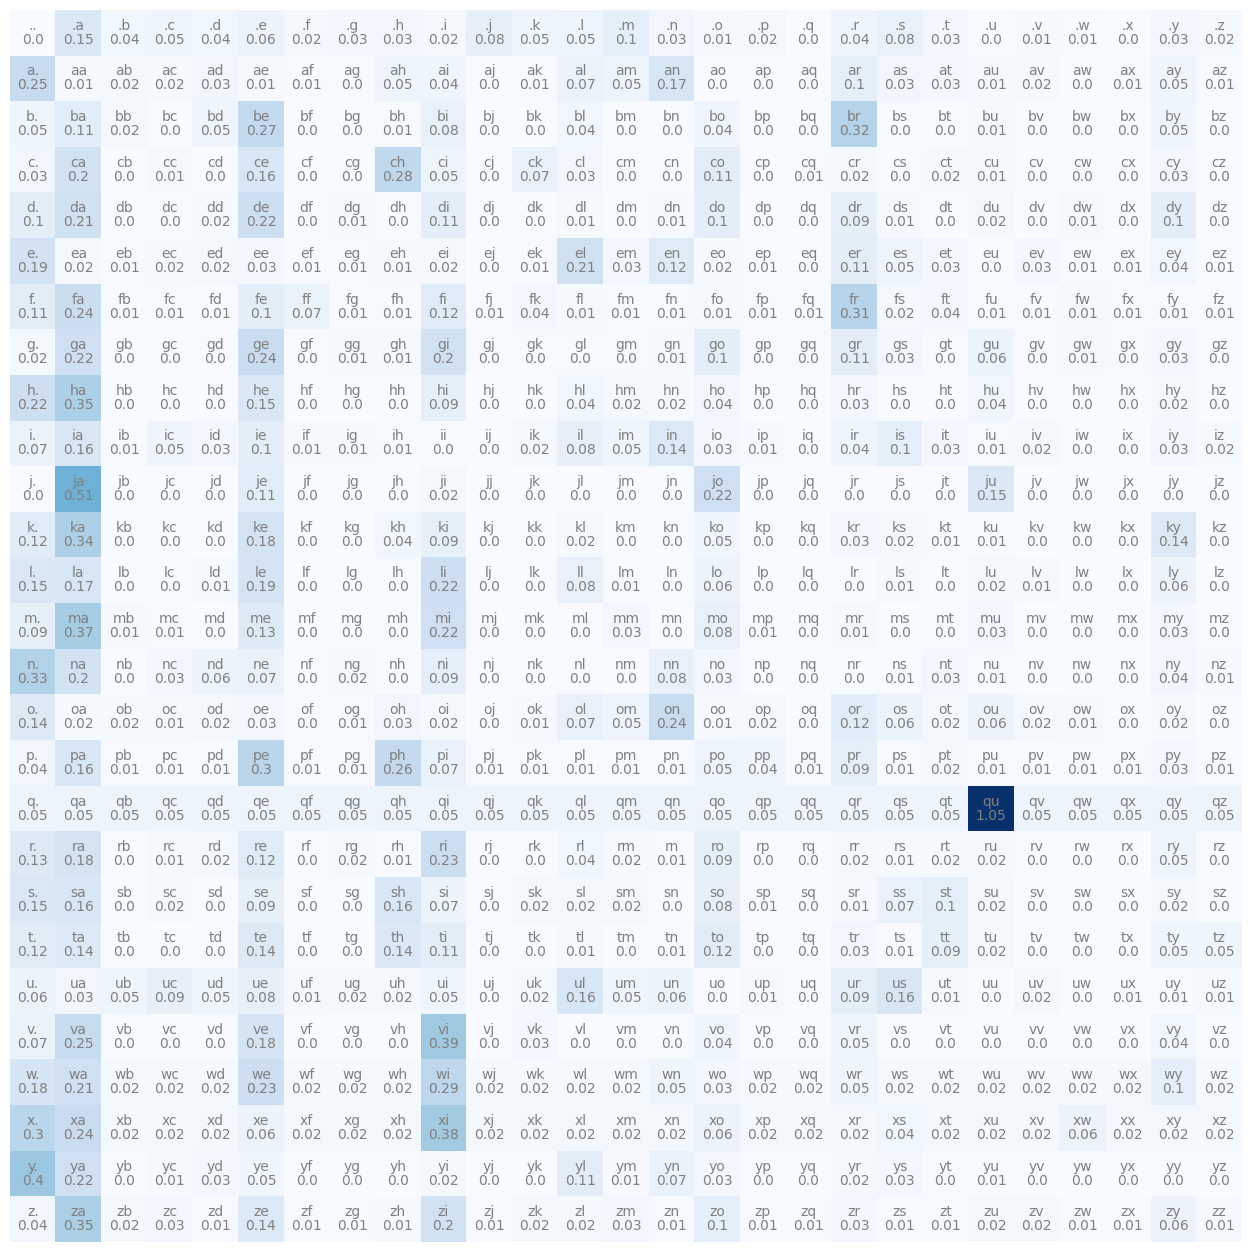

In [173]:
plt.figure(figsize=(16,16))
plt.imshow(P, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itoc[i] + itoc[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, round(P[i, j].item(),2), ha="center", va="top", color='gray')
plt.axis('off');

In [174]:
torch.multinomial(P[i], num_samples=1, replacement=True).item()

5

In [175]:
words = []

for _ in range(10):
    out = ''
    i = 0
    
    while len(out) == 0 or i != 0:
        out += itoc[i]
        i = torch.multinomial(P[i], num_samples=1, replacement=True).item()
    
    out += itoc[i]
    words.append(out)

words

['.ana.',
 '.kela.',
 '.ame.',
 '.arily.',
 '.ttamey.',
 '.r.',
 '.lloty.',
 '.sarorn.',
 '.smiy.',
 '.rca.']

In [375]:
log_likelihood = 0.0
c = 0

for word in names_store[:]:
    word = "." + word + "."
    for c1, c2 in zip(word, word[1:]):
        c += 1
        ix1, ix2 = ctoi[c1], ctoi[c2]
        prob = P[ix1][ix2]
        logprob = P[ix1][ix2].log()
        log_likelihood += logprob
        # print(c1, c2, )

-log_likelihood/c

tensor(2.3716)

In [394]:
k = 0
journal = []
xs, ys = [], []

for word in names_store:
    word = "." + word + "."
    for c1, c2 in zip(word, word[1:]):
        c += 1
        ix1, ix2 = ctoi[c1], ctoi[c2]
        xs.append(ix1)
        ys.append(ix2)
        # print(c1, c2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
xs_enconded = torch.nn.functional.one_hot(xs, num_classes=27).float()
W = torch.randn((27, 27), requires_grad=True)
xs_enconded.shape, ys.shape, W.shape

(torch.Size([22449, 27]), torch.Size([22449]), torch.Size([27, 27]))

In [ ]:
for _ in range(1000):
    k += 1
    # forward
    logits = xs_enconded @ W
    counts = logits.exp()
    probs = counts/counts.sum(1, keepdim=True)
    
    # loss
    loss = -probs[torch.arange(xs.nelement()), ys].log().mean()
    
    # backward
    W.grad = None
    loss.backward()
    
    # update
    W.data += -0.1 * W.grad

    print(f"iter {k}; {loss=}")
    journal.append((k, loss))

In [407]:
journal[-100:]

[(6901, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6902, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6903, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6904, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6905, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6906, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6907, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6908, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6909, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6910, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6911, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6912, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6913, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6914, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6915, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6916, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6917, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6918, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6919, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6920, tensor(2.3951, grad_fn=<NegBackward0>)),
 (6921, tensor(2.395

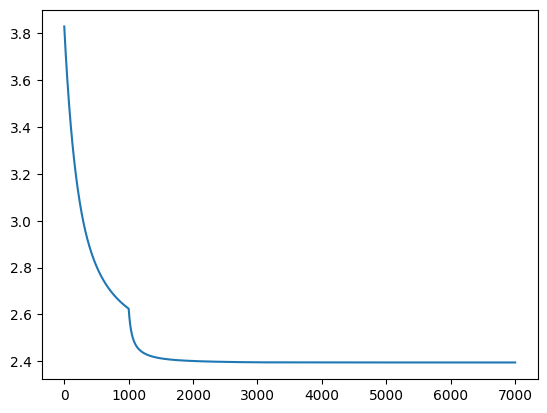

In [406]:
plt.plot([x[0] for x in journal], [x[1].item() for x in journal])